In [2]:
import numpy as np
import glob
import torch
import json
import torch.nn.functional as F
import nibabel as nib
import huggingface_hub


from matplotlib import pyplot as plt
from PIL import Image

from modeling.BaseModel import BaseModel
from modeling import build_model
from utilities.distributed import init_distributed
from utilities.arguments import load_opt_from_config_files
from utilities.constants import BIOMED_CLASSES


from inference_utils.inference import interactive_infer_image
from inference_utils.output_processing import dice_volume, iou_volume, hausdorff_distance_volume
from inference_utils.processing_utils import read_nifti_only, process_intensity_image, resize_to_original

C:\Users\Toni\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Deformable Transformer Encoder is not available.


C:\Users\Toni\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\kornia\feature\lightglue.py:30: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [5]:
with open('tokens.json') as f:
    tokens = json.load(f)

In [6]:
HF_TOKEN = tokens['hugging_face']

huggingface_hub.login(HF_TOKEN)

### Model Setup

In [7]:
opt = load_opt_from_config_files(["configs/biomedparse_inference.yaml"])
opt = init_distributed(opt)

# Load model from pretrained weights
pretrained_pth = 'pretrained/biomed_parse.pt'
pretrained_pth = 'hf_hub:microsoft/BiomedParse'

model = BaseModel(opt, build_model(opt)).from_pretrained(pretrained_pth).eval().cuda()
with torch.no_grad():
    model.model.sem_seg_head.predictor.lang_encoder.get_text_embeddings(BIOMED_CLASSES + ["background"], is_eval=True)


C:\Users\Toni\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
$UNUSED$ criterion.empty_weight, Ckpt Shape: torch.Size([17])


### Utility Functions

In [15]:
!pip install pydicom nibabel SimpleITK


def inference_nifti(file_path, text_prompts, is_CT, site=None):
    image, nii = read_nifti_only(file_path)
    test_3D = np.empty((1, image.shape[0], image.shape[1]))

    for slice_iter in range(image.shape[2]):
        
        # Resize and padding
        image_array = process_intensity_image(image[: ,: , slice_iter], is_CT, site)
        # Get prediction
        pred_mask = interactive_infer_image(model, Image.fromarray(image_array), text_prompts)

        # im = Image.fromarray((pred_mask[0]*255).astype(np.uint8))
        # im.save(f"pred_masks\slice_{slice_iter}.png")

        # Resize to original size
        resize_image = resize_to_original(pred_mask, image.shape[0], image.shape[1])

        # Stack back together
        test_3D = np.vstack((test_3D, resize_image))

    print(f"Patient {file_path[14:20]} is complete")

    # Remove inital empty row
    test_3D = np.delete(test_3D, (0), axis=0)

    final_img = nib.Nifti1Image(test_3D.transpose(1,2,0), nii)
    nib.save(final_img, f'results/CT_patient_{file_path[14:20]}.nii.gz')

    return test_3D



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: C:\Users\Toni\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [17]:
img_paths = 'data//CT//img//*'
is_CT = True
site = 'abdomen'
text_prompts = ['pancreatic tumor']

for img_path in glob.iglob(img_paths):
    # The result predictions are soft, hence why he thresholds 0.5 to set make them 0-1
    image =  inference_nifti(img_path, text_prompts, is_CT=is_CT, site=site)

Patient 100000 is complete
Patient 100001 is complete
Patient 100002 is complete
Patient 100003 is complete
Patient 100004 is complete
Patient 100005 is complete
Patient 100006 is complete
Patient 100007 is complete
Patient 100008 is complete
Patient 100009 is complete
Patient 100010 is complete
Patient 100011 is complete
Patient 100012 is complete
Patient 100013 is complete
Patient 100014 is complete
Patient 100015 is complete
Patient 100016 is complete
Patient 100017 is complete
Patient 100018 is complete
Patient 100019 is complete
Patient 100020 is complete
Patient 100021 is complete
Patient 100022 is complete
Patient 100023 is complete
Patient 100024 is complete
Patient 100025 is complete
Patient 100026 is complete
Patient 100027 is complete
Patient 100028 is complete
Patient 100029 is complete
Patient 100030 is complete
Patient 100031 is complete
Patient 100032 is complete


KeyboardInterrupt: 

In [14]:
patients = []

for img_path in glob.iglob('data//CT//img//*'):
    # TODO add regex for stricter selection
    patients.append(img_path[14:20])

patients

['100000',
 '100001',
 '100002',
 '100003',
 '100004',
 '100005',
 '100006',
 '100007',
 '100008',
 '100009',
 '100010',
 '100011',
 '100012',
 '100013',
 '100014',
 '100015',
 '100016',
 '100017',
 '100018',
 '100019',
 '100020',
 '100021',
 '100022',
 '100023',
 '100024',
 '100025',
 '100026',
 '100027',
 '100028',
 '100029',
 '100030',
 '100031',
 '100032',
 '100033',
 '100034',
 '100035',
 '100036',
 '100037',
 '100038',
 '100039',
 '100040',
 '100041',
 '100042',
 '100043',
 '100044',
 '100045',
 '100046',
 '100047',
 '100047',
 '100047',
 '100047',
 '100047',
 '100048',
 '100049',
 '100050',
 '100051',
 '100052',
 '100053',
 '100054',
 '100055',
 '100056',
 '100057',
 '100058',
 '100059',
 '100060',
 '100061',
 '100062',
 '100063',
 '100064',
 '100065',
 '100066',
 '100067',
 '100068',
 '100069',
 '100070',
 '100071',
 '100072',
 '100073',
 '100074',
 '100075',
 '100076',
 '100077',
 '100078',
 '100079',
 '100080',
 '100081',
 '100082',
 '100083',
 '100084',
 '100085',
 '100086',

In [6]:
# For single file test
patients = ['005']

for patient in patients:

    path_label = f'data//CT//gt//pancreas_{patient}.nii.gz'
    label, nii = read_nifti_only(path_label)

    # One hot encode multiple classes
    label_one_hot = F.one_hot(torch.tensor(label).long(), num_classes=len(np.unique(label)))
    print("Unique values currently are :", torch.unique(label_one_hot))

    path_pred = f'results//CT_patient_{patient}.nii.gz'
    pred, nii = read_nifti_only(path_pred)

    pred = torch.tensor(pred)
    # Threshold soft predictions to hard, same as the writer
    pred = (pred > 0.5).float()


    dice = dice_volume(torch.permute(label_one_hot[:,:,:,2], (2, 0, 1)), torch.permute(pred, (2, 0, 1)))
    iou = iou_volume(torch.permute(label_one_hot[:,:,:,2], (2, 0, 1)), torch.permute(pred, (2, 0, 1)))
    hausdorff = hausdorff_distance_volume(torch.permute(label_one_hot[:,:,:,2], (2, 0, 1)), torch.permute(pred, (2, 0, 1)))

    print(f"3D_DICE score for patient {patient} is : {dice.mean():05.3f}")
    print(f"3D_IoU score for patient {patient} is : {iou.mean():05.3f}")
    print(f"3D_HD score for patient {patient} is : {hausdorff}")

Unique values currently are : tensor([0, 1])
3D_DICE score for patient 005 is : 0.064
3D_IoU score for patient 005 is : 0.033
3D_HD score for patient 005 is : 149.52257354660534


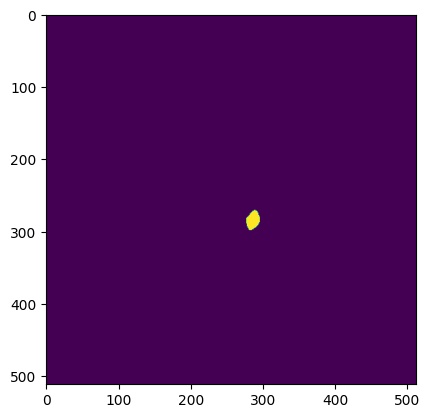

In [7]:
imgplot = plt.imshow(torch.permute(label_one_hot, (2,3,0,1))[52, 2, :, :])
plt.show()

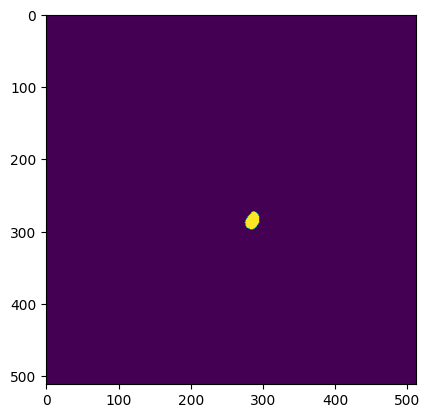

In [8]:
imgplot = plt.imshow(torch.permute(pred, (2, 0, 1))[52])
plt.show()